# Topological Data Analysis of Nanomaterials with Near-Infrared Fluorescence

### Abstract

Recent studies have shown interest in near-infrared (NIR) silver nanoclusters, a class of nanomaterials that is held together by a DNA strand. These nanomaterials have great promise as biosensors due to their NIR flourescence and their inherent compatibility with DNA. A direct application of a biosensor like this is deep tissue imaging. However, nanomaterials with a NIR flourescence are extremely rare, which makes them difficult to research empirically. Research done by Dr. Petko Bogdanov of SUNY Albany and Dr. Stacy Copp of UC Irvine has successfully leveraged machine learning methodologies to generate synthetic DNA strands that have this NIR property, in order to have an ample amount of them to study. In this work, we will analyze the raw data used in their recent paper, Property-Isometric Variational Autoencoders for Sequence Modeling and Design, by E. Sadeghi et al., and attempt to make connections with DNA strands and NIR flourescence using Topological Data Analysis methodologies.

This dataset contains 3257 sequences of DNA, where only 220 are considered to be Near Infrared. We determine if we can find meaningful clusters with properties that can be used to explain occurrances of NIRs.

Link to Paper : https://arxiv.org/pdf/2509.14287

# Install packages

In [1]:
!pip install numpy
!pip install pandas
!pip install openpyxl
!pip install matplotlib
!pip install scipy

# Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import squareform


## Utility Functions

### edit_distance_matrix

In [3]:
def edit_distance(string_1:str, string_2:str, verbose = False)->int:
    """
    Computes the edit distance between two strings of equal length. used as a helper function for `edit_distance_matrix()`

    Parameters
    ----------
    string_1 : str
        The first string to be compared.
    string_2 : str
        The second string to be compared.

    verbose : bool
        False by default. Prints out each pair of strings and their edit distance if set to True.

    Returns
    -------
    int
        The edit distance of ``string_1`` and ``string_2``.

    """
    # all dna sequences in the dataset are of length 10, and are all strings
    if len(string_1) != len(string_2):
        print("Error, incompatible lengths", string_1,':',len(string_1),',', string_2),':',len(string_2)
        return

    # make each string into a list of chars
    tokenized_1 = list(string_1)
    tokenized_2 = list(string_2)

    #distance starts at 0, we increment it as we find more discrepencies
    distance = 0

    for i in range(len(string_1)):
        if verbose == True:
            print(i, string_1[i], string_2[i])
        if tokenized_1[i] != tokenized_2[i]:
            distance += 1
    return distance



def edit_distance_matrix(string_list:list, sparse = False)->pd.DataFrame:
    """
    Computes the edit distance matrix of a list of strings.

    Parameters
    ----------
    string_list : list
        The list of strings to make the edit distance matrix of.

    sparse : bool
        False by default. Returns an upper triangular edit distance matrix stored in a dataframe. all values under the diagonal will be set to 0.

    Returns
    -------
    DataFrame
        A pandas Dataframe storing the edit distance matrix of ``string_list``, with the index and column names acting as identifying labels.

    """
    n = len(string_list)
    # Dataframes are easily labeled so we are going to store the distance matrix in there vs a numpy array
    # we start by initializing it with a square matrix of all zeros, we will fill in the actual values in the loop
    distance_matrix = pd.DataFrame(np.zeros((n,n)))
    #the index will function as a label for each row, so it corresponds easily with the column names
    distance_matrix.index = string_list
    # the column names are obviously a label for each column
    # since we dont really care about the numerical index of anything here and the actual dna sequence labels,
    # this will be very convenient
    distance_matrix.columns = string_list
    if sparse == False:
        for i in range(len(string_list)):
            # we only need to iterate across the upper triangular matrix since it is symmetric
            for j in range(i+1,len(string_list)):
                d = edit_distance(string_list[i], string_list[j])
                # distance matrices are symmetric so we apply the same value twice every iteration
                distance_matrix.iloc[i,j] = d
                distance_matrix.iloc[j,i] = d
    else: # sparse == True, upper triangular matrix will be returned
        for i in range(len(string_list)):
            for j in range(i+1,len(string_list)):
                d = edit_distance(string_list[i], string_list[j])
                distance_matrix.iloc[i,j] = d
    return distance_matrix

### get_cluster

In [4]:
def get_cluster(clusters:pd.DataFrame, cluster_num:int):
    """
    returns a single cluster specified by its numeric label from a Dataframe containing clusters

    Parameters
    ----------
    clusters : DataFrame
        a dataframe containing a list of the sequence names, and their assigned clusters
    cluster_num: int
        The numeric value of the desired cluster to be returned
    Returns
    -------
    DataFrame
        The specified cluster to be fetched.

    """
    # isolate the desired cluster by 'cluster_num' id, in a dataframe full of all the clusters
    # and return only that cluster by dropping all other rows (which are null-valued because of pd.where() ).
    return clusters.where(clusters['Cluster']==cluster_num).dropna()

### count_clusters

In [5]:
def count_clusters(cluster_routine, threshold:int):
    """
    Clusters data with respect to a fitted cluster routine, and prints the amount of data points,
    the amount of clusters, and the threshold used. This can come in handy as if clusters are far too big or small,
    we may not be interested in exploring them further. For example, if we run this and get back 4 clusters for 3257 data
    points, it is a fair assumption that we set the threshold way too high and this will not be suitable for analysis.

    Parameters
    ----------
    clusters_routine :
        the scipy implementation of the hierarchal clustering algorithm to be used. Already fitted to the data.
    threshold: int
        the threshold where we separate the clusters (where we would cut the dendogram)

    Returns
    -------
        None
    """
    # we split up the clusters according to the passed threshold
    clusters = fcluster(cluster_routine, threshold,  criterion='distance')
    # we convert to a pandas series so we can use the unique() function to count the clusters
    print(clusters.shape[0], 'datapoints comprising',
          len(pd.Series(clusters).unique()),'clusters with threshold', threshold)
    # this is primarily for exploratory data analysis so this doesnt return anything, since often
    # we probably wont care about what this is calculating. in the event that we do, we can rerun it since
    # fcluster() is pretty fast so its not that big of a deal

### cluster_means

In [6]:
def cluster_means(clusters_df:pd.DataFrame):
    '''
    Given a dataframe containing all data points and their corresponding clusters,
    determines the means for the wavelengths, intensity weights, and peak widths of the brighest peak
    for each dna sequence in the cluster. Additionally, the cluster sizes and the ratio of near-infrared
    sequences are stored as well. These values are stored in a dataframe, and that dataframe is returned.
    '''
    # everythings simpler in an iterable list
    indices = clusters_df['Cluster'].value_counts().sort_index().tolist()

    weight_column = []
    wav_column = []
    peak_width_column = []
    shuffled_index = []
    cluster_size_col = []
    nir_ratio_col = []

    # the cluster labels start at 1, so we iterate starting at 1
    for i in range(1, len(indices)+1):
        #isolate each cluster
        cluster_i = clusters_df.where(clusters_df['Cluster']==i).dropna()

        # we must check for the existence of near infrared peaks first to avoid zero division or
        # attempting to divide the None value when we calculate the ratio.
        # the index of the return value of value_counts() is a list of the unique values, since
        # the actual return value is a pandas series where the only column is the counts of said values,
        # so we check if the desired value is in the index
        if 'N' in cluster_i['Brightest Peak'].value_counts().index:
            nir_ratio = cluster_i['Brightest Peak'].value_counts()['N']/len(cluster_i.index)
        # the value of 0 is manually assigned if there are no near infrared peaks
        # no math is required for that
        else:
            nir_ratio = 0

        #store the nir ratio
        nir_ratio_col.append(nir_ratio)

        # we repeatedly append the original indices of the values in the cluster, so we may maintain an ordering
        # of the data when this is finished.
        # pandas dataframe indices do not change unless explicitly forced to,
        # so for each iteration/cluster, we know the original position of each value in the cluster
        shuffled_index+=list(cluster_i.index)

        # calculate the 3 means for the cluster
        wav_mean = cluster_i['Wavelength'].mean()
        weight_mean = cluster_i['Weight'].mean()
        peak_width_mean = cluster_i['Peak Width'].mean()

        #store the cluster size
        cluster_size_col.append(len(cluster_i.index))

        # store the means
        weight_column += [weight_mean]
        wav_column += [wav_mean]
        peak_width_column += [peak_width_mean]

    # organize the collected data into a dataframe to be returned

    # the cluster labels are not zero indexed so we just stick with that for the sake of consistency, and give it its own column
    cluster_count = list(range(1, len(clusters_df.index)+1))
    mean_df = pd.DataFrame([ weight_column, wav_column, peak_width_column, nir_ratio_col, cluster_size_col,cluster_count]).transpose().dropna()
    # everythings easier with a nice name at the end
    mean_df.columns = ['Weight Mean', 'Wavelength Mean', 'Peak Width mean', 'NIR ratio' , 'Cluster Size','Cluster #']

    return mean_df


### return_all_clusters

In [7]:
def return_all_clusters(cluster_routine, threshold, labels, dataset:pd.DataFrame):
    """
    Takes a given dataset and clusters it according to the passed routine form, and the desired threshold.
    Returns a dataframe with columns containing the sequence labels, their wavelength class, brightest peak wavelength, the location of their NIR peak, and their assigned cluster.

    Parameters
    ----------
    clusters_routine :
        the scipy implementation of the hierarchal clustering algorithm to be used
    cluster_num: int
        the threshold where we separate the clusters (where we would cut the dendogram)
    dataset: Dataframe
        The original dataset

    Returns
    -------
    DataFrame
        A dataframe of all the sequences, cluster assignments and various information on each sequence.

    """
    # make an empty dataframe to be added to
    clustered_df = pd.DataFrame()
    # get the clusters with respect to the given threshold
    clusters = fcluster(cluster_routine, threshold, criterion='distance')
    # we get the corresponding sequences. This is somewhat redundant if we are using the entire dataset
    # every piece of code here with ".where(dataset['Sequence'].isin(labels)).dropna()" is in the event that we arent using the whole dataset.
    # for the sake of robustness i am leaving it here but it doesnt do anything since ultimately i was able to use the whole dataset
    clustered_df['Sequence'] = dataset['Sequence'].where(dataset['Sequence'].isin(labels)).dropna()
    # the original dataset is named terribly so we will correct a lot of that here.
    # the wavelength class is the string of length 1-4 of wav classes. for example, 'N' would be near infrared single peak, FGN would be three peaks with far red, green, near infrared, and so on

    clustered_df['Wavelength Class'] = dataset['class 4'].where(dataset['Sequence'].isin(labels)).dropna()
    # rename the columns for the weight, wavelength, and peak width of the brightest peak of the sequence
    # something that could be promising for further analysis is doing this for every single peak
    clustered_df['Weight'] = dataset['Component 1 a log10'].where(dataset['Sequence'].isin(labels)).dropna()
    clustered_df['Wavelength'] = dataset['Component 1 b (wavelength)'].where(dataset['Sequence'].isin(labels)).dropna()
    clustered_df['Peak Width'] = dataset['Component 1 c (wavelength)'].where(dataset['Sequence'].isin(labels)).dropna()
    # ultimately we do mainly care about the brightest peak, i.e the first char in the Wavelength class string, so we store that in its own column for ease
    clustered_df['Brightest Peak'] = clustered_df['Wavelength Class'].str[:1]
    # a numerical index of where we may find the letter N in the wavelength class
    clustered_df['NIR peak location'] = clustered_df['Wavelength Class'].apply(lambda x: str(x).find('N'))
    # the numeric label of the clusters
    clustered_df['Cluster'] = clusters

    print(clustered_df.shape[0], 'datapoints comprising',
          len(clustered_df['Cluster'].unique()),'clusters with threshold', threshold)

    return clustered_df

### Cluster_Of_Interest class

In [8]:
class Cluster_Of_Interest():
    '''
    A Python class that contains a cluster of interest and all pertinant information about it to be
    conveniently stored in one place. The cluster size, linkage method, threshold, any additional information
    about the cluster, a distance matrix of all the dna sequences in the cluster, a list of dna sequences,
    a flattened cluster analysis dataframe, all corresponding wavelengths are stored.
    This class also features a `report()` function which prints out a quick summary of the available information
    regarding the cluster.
    '''


    def __init__(self, all_clusters:pd.DataFrame, cluster_label:int, linkage_method:str, threshold:int, original_data:pd.DataFrame, info=None):
        # the actual cluster dataframe
        self.cluster = get_cluster(all_clusters, cluster_label)

        # the size of the cluster
        self.size = len(self.cluster.index)

        # the numeric cluster label
        self.cluster_number = self.cluster['Cluster'].astype(int).iloc[0] # these are all the same so any index works

        # the linkage method used. this doesnt actually do anything, but it is helpful for when i was trying many
        # different things and needing to keep track of how i got each result
        self.linkage = linkage_method

        # the threshold used. This also doesnt do anything and is only here for recordkeeping
        self.threshold = threshold

        # in case i wanted to add any notes about some cluster, i could store them here
        self.info = str(info)

        # a distance matrix of the sequences withing the cluster. ideally we want a lot of small values
        self.distance_matrix = edit_distance_matrix(self.cluster['Sequence'].tolist())

        # given how edit_distance_matrix() is coded, the index is the list of sequences
        self.sequences = self.distance_matrix.index

        # this is just a cosmetic detail, it helps to know what sequences we actually care about
        # for example i probably dont care about 'ACTGGGACCA, GGRF' but i do care about 'GGCGGGACCA, NF'
        self.distance_matrix.index = self.cluster['Sequence']+" , "+ self.cluster['Wavelength Class']
        self.distance_matrix.columns = self.cluster['Sequence']+" , "+ self.cluster['Wavelength Class']

        # the reoccurances of counts in the distance matrix. we want a lot of small numbers here.
        # we use squareform since that eliminates the redundencies of a symmetric matrix,
        # which returns a numpy array. we then make it into a pandas series so we can use value_counts() to
        # easily count how many times each of the 9 possible distances occur within the cluster
        self.distance_counts = pd.Series(squareform(self.distance_matrix)).value_counts()

        # counting the reoccurances of each wavelength class
        self.distinct_peaks = self.cluster['Wavelength Class'].value_counts()

        # counting the reoccurances of the top 2 brighest peaks of each sequence. the paper did this so i figured id include it
        self.top_2_peaks = self.cluster['Wavelength Class'].str[:2].value_counts()

        # counting the reoccurances of the brightest peak of each sequence. this is the most important one.
        self.brightest_peaks = self.cluster['Brightest Peak'].value_counts()

    def report(self):
        # print('\n-----------------------------------------------------------')
        print('Cluster #'+ str(self.cluster_number)+ '\nSize: ' +  str(self.size)+ ', Linkage: '+ self.linkage + ', threshold: '+
               str(self.threshold)+'\nAdditional Info: '+ self.info + '\n\nDistance Counts\n' + str(self.distance_counts)+ '\n\n' + str(self.brightest_peaks)+ '\n\n' + str(self.top_2_peaks) )




### fitted_cluster_routines

In [9]:
def fitted_cluster_routines(distance_matrix:pd.DataFrame):
    """
    Takes a distance matrix stored in a pandas DataFrame, flattens the matrix, fits the flattened data to
    various hierarchal clustering routines, and returns all the routines.
    These routines are ward, single, average, complete, linkage, centroid, weighted, and median.
    Each routine is from the scipy hierachal clustering package. This is put in a function in the event that
    a different/filtered distance matrix is desired for fitting the routines.

    Parameters
    ----------

    distance_matrix: Dataframe
        The distance matrix to be fitted to the hierarchal clustering routines

    Returns
    -------
    8 ndarrays
        Arrays containing the clusterings of the data, with respect to each clustering routine.
    """
    # flatten/remove redundancies from the distance matrix
    data_flattened = squareform(distance_matrix)

    matrix_size = len(distance_matrix.index)

    # fit the data to as many linkage methods as possible in the hopes that one works well

    ward = sch.ward(data_flattened)
    ## single was very bad and took forever to run for some reason, so this is omitted
    # however i did try it so just to make that clear im leaving it here
    # single = sch.single(data_flattened)
    average = sch.average(data_flattened)
    complete = sch.complete(data_flattened)
    ## this seems to be the same exact thing as single linkage
    # linkage = sch.linkage(data_flattened)
    centroid = sch.centroid(data_flattened)
    weighted = sch.weighted(data_flattened)
    median = sch.weighted(data_flattened)
    print("distance matrix is of size", matrix_size,'x', matrix_size)
    return ward, average, complete, centroid, weighted, median

### cluster_mean_distance

In [10]:
def cluster_mean_distance(mean_df:pd.DataFrame, cluster_label_of_interest:int,  n:15):
    '''
    Given a DataFrame of all cluster means, and a numeric label representing a cluster of interest,
    returns a DataFrame containing each cluster's euclidean distance from the cluster of interest
    with respect to each clusters average intensity weights, wavelength, and peak width.
    '''
    # get the weight, wavelength, and peak width means corresponding to the cluster label of interest
    # in more detail, we get the single row of the single specified mean column corresponding to the desired cluster label/number,
    # drop all other rows since they will be null-valued due to side effects of where(),
    # then get the single element in each row/column specification via iloc[0] so we have an actual number,
    # and not a pandas series of length 1 or something
    weight = mean_df['Weight Mean'].where(mean_df['Cluster #']==cluster_label_of_interest).dropna().iloc[0]
    wavelength = mean_df['Wavelength Mean'].where(mean_df['Cluster #']==cluster_label_of_interest).dropna().iloc[0]
    peak_width = mean_df['Peak Width mean'].where(mean_df['Cluster #']==cluster_label_of_interest).dropna().iloc[0]

    # convert columns into lists so it is simple to iterate over
    all_weight = mean_df['Weight Mean'].tolist()
    all_wavs = mean_df['Wavelength Mean'].tolist()
    all_peak_width = mean_df['Peak Width mean'].tolist()

    #we will store the euclidean distances here
    distances = []

    for i in range(len(mean_df.index)):
        # for each group of means, we calculate the euclidean distance from them to the means of interest
        x_term = (weight - all_weight[i])**2
        y_term = (wavelength - all_wavs[i])**2
        z_term = (peak_width - all_peak_width[i])**2
        l2 = np.sqrt(x_term + y_term + z_term)
        distances.append(l2) # store the distances when it is done

    # since the mean_df is already sorted by cluster number, this list of distances will also be sorted that way.

    # create a dynamically changing title for the column so things are easy to keep track of
    title = 'distance from cluster ' + str(cluster_label_of_interest)

    #store results in a dataframe for ease
    df = pd.DataFrame()

    # cluster labels start at 1, not 0
    df['Cluster #'] = list(range(1,len(mean_df)+1))
    # the dynamically changing title will be used as the column name
    df[title] = distances
    # sort them by distance, we want the smallest ones on top
    df = df.sort_values(by = title)

    # a list of the numeric labels of the top n = 15 closest clusters to the cluster of interest,
    # WRT the euclidean distance of the means. since we do compute the euclidean distance of EVERY
    # possible sequence pair, the shortest distance will be 0, since we inevitably compare the cluster
    # of interest with itself. since we dont care about that, we slice the top with [1:n+1] to omit this 0 value,
    # and get the top 15 AFTER the useless 0 value.
    # this value is left in there so that the natural ordering of the distances by the cluster number/labels isnt affected
    top_n = df['Cluster #'].iloc[1:n+1].tolist()

    # return both the dataframe of distances and the list of cluster labels.
    # the dataframe is handy for further analysis, but in this work we will just be using the list
    return df, top_n



### filtered_distance_matrix

In [11]:
def filtered_distance_matrix(dataset:pd.DataFrame, distance_matrix:pd.DataFrame, wav = 'N', contains = True, startswith = False):
    '''
    Created a filtered distance matrix of DNA sequences from the original dataset and its corresponding distance matrix,
    based on wavelength criteria. One of the desired wavelength identifiers `['N', 'R', 'G', 'F']` is set to `wav`.
    The filtered distance matrix is returned.
    '''
    #placeholder to avoid scoping errors, python freaks me out sometimes
    filtered_sequences = None
    if wav.upper() not in ['N', 'R', 'G', 'F']:
        print('Invalid wav selection. Use N, R, G or F')
    # put all sequences in a list such that there exists the 'N' (near infrared) wavelength on at least one of the peaks
    if contains == True:
        filtered_sequences = dataset['Sequence'].where(dataset['class 4'].str.contains(wav.upper())).dropna().tolist()

    # put all sequences in a list such that the brightest peak is of the 'N' (near infrared) wavelength
    elif startswith == True:
        filtered_sequences = dataset['Sequence'].where(dataset['class 4'].str.startswith(wav.upper())).dropna().tolist()
    # filter the distance matrix to only include those sequences

    # using the filtered_sequences list, and the fact that the distance_matrix dataframe is conveniently
    # labeled symmetrically with the sequence strings on the columns AND the index,
    # we can filter the distance matrix of the whole dataset by simple indexing, and then
    # by location by value (loc) to get the columns and the rows that we want.
    filtered_distance_matrix = distance_matrix[filtered_sequences]
    filtered_distance_matrix = filtered_distance_matrix.loc[filtered_sequences]

    # return the distance matrix and the list of the sequences used in it
    return filtered_distance_matrix, list(filtered_distance_matrix.index)

### top_n_category_analysis

In [12]:
def top_n_category_analysis(mean_df:pd.DataFrame, all_clusters_df:pd.DataFrame,original_data:pd.DataFrame,
                            metric:str, iter = 60, verbose = True):
    '''
    Given a specified metric, determines which clusters have the highest value with respect to that metric.
    the available metrixs are peak width mean, weight mean, wavelength mean, ratio of near-infrared dna strands
    compared to all others, and the cluster size. the criteria is such because the highest means all correspond to
    near infrared strands, we want a cluster of a reasonable size, and we also want there to be a large amount of
    near infrareds in the cluster.
    '''

    # this if/else chain saved me some time with readability and testing/exploratory data analysis.
    if metric == 'peak':
        metric_string = 'Peak Width mean'
    elif metric == 'weight':
        metric_string = 'Weight Mean'
    elif metric == 'wav':
        metric_string = 'Wavelength Mean'
    elif metric == 'nir':
        metric_string = 'NIR ratio'
    else:
        metric_string = 'Cluster Size'

    i=1
    # presuming we only care about the cluster labels, they will be stored in this empty list
    labels = []
    # we want the dataframe of means, sorted by whatever criteria we specified
    # we also only want however many of the top n means specified by the iter variable
    for c_ix in mean_df.sort_values(by=metric_string, ascending=False)['Cluster #'].head(iter):
        # print(c_ix)
        c_complete = Cluster_Of_Interest(all_clusters_df, c_ix, 'Complete', 6, original_data)
        # if we want to do some exploratory data analysis data analysis, this should be true
        # prints out some helpful information
        if verbose == True:
            print('\n-----------------------------------------------------------')
            print('Rank',i, 'with respect to',metric_string)
            print()
            c_complete.report()
            print()
            print(mean_df.where(mean_df['Cluster #'] == c_ix).dropna())
            print()
            i+=1
        else: # if we just want the clusters that meet the criteria when we can just record the labels and move on
              # since we arent doing tons of exploratory data analysis anymore this is what is used in the code below
            labels.append(c_complete.cluster_number)

    if verbose == True:
        return # if we just wanted to check things out just return nothing, we dont need anything yet

    return labels # if we do care about the labels then return those


### top_category_clusters

In [13]:
def top_category_clusters(mean_df:pd.DataFrame, all_clusters:pd.DataFrame,
                          original_data:pd.DataFrame,categories:list, top_n = 60 ):# , all_categories = True):
    '''
    Determines which clusters have the highest mean values, ratio of NIR dna strands, and cluster sizes,
    and then determines which clusters have the highest values with respect for all of the criteria at once.
    These clusters are assumed to be clusters of value since the brightest clusters are typically near infrared.
    if all_categories is False, we omit the ratio of NIR dna strands since this has demonstrated to be the most
    restrictive of the criteria. if all_categories is True, we include it in the criteria.
    '''
    if categories == None:
        categories = ["peak", "weight", "wav", 'size', 'nir']

    top_cluster_lists = None #python scares me with scoping issues sometimes idk
    for c in categories:
        # we get just the labels of the top n clusters wrt each category
        top_clusters = top_n_category_analysis(mean_df, all_clusters, original_data, c, top_n, verbose=False)
        # we need to initialize the first iteration into a set,
        # since an intersection with the empty set is still the empty set
        if top_cluster_lists == None:
            top_cluster_lists = set(top_clusters)
        #after the first iteration, we have an initialized nonempty set so we may start taking intersections
        else:
            top_cluster_lists = top_cluster_lists.intersection(set(top_clusters))

    # return the intersections of all the top 30 cluster labels with respect to all categories
    # in theory, the best clusters in general will be returned
    print(len(top_cluster_lists), 'clusters meet all criteria.')
    print('Cluster labels:', np.array(top_cluster_lists))# numpy arrays print nicely, the text wraps by itself so long lists are easy to read
    print()
    # sort the list of top clusters so it is easier to keep track of.
    return sorted(list(top_cluster_lists))

### cluster_list_report

In [14]:
def cluster_list_report(cluster_labels:list, all_clusters:pd.DataFrame,
                        linkage:str, threshold:int, original_data:pd.DataFrame):
    '''
    Given a list of specified cluster labels and a DataFrame of all the clusters, puts each specified cluster in a
    `Cluster_Of_Interest` class, and calls the `report()` function for each class instance. This is helpful if we have
    a list of cluster labels that we are interested in.
    '''


    # for each cluster, create a Cluster_Of_Interest class instance and call its report() function.
    # these are not stored in memory since this is just a wrapper for report()
    for i in cluster_labels:
        c = Cluster_Of_Interest(all_clusters, i, linkage, threshold, original_data)

        print('\n-----------------------------------------\n')
        c.report()

In [15]:
def cluster_list_wav_count(cluster_labels:list, all_clusters:pd.DataFrame,
                          linkage:str, original_data:pd.DataFrame, threshold:int, top_2 = True)->pd.DataFrame:
    '''
    Takes a specified list of clusters, gets the counts of the brightest wavelengths for each dna strand
    in each cluster, and then combines the counts across all the clusters. This is used to analyze how one cluster
    relates to the top 10 closest clusters to it in the "mean space", and shows what wavelengths are associated.
    It is of interest to us how a cluster filled with NIR wavelengths relates to other clusters near it.
    if top_2 is True, we get the top 2 brightest wavelengths (ex: FR). if it is false, we get only the brightest
    wavelength (ex: N)
    '''
    # depending if we want the brightest or top 2 brightest wavelength classes, the column name will be different
    if top_2 == True:
        column_name = 'Wavelength Class'
    else:
        column_name = 'Brightest Peak'

    # we will store all of the value counts in this list, to later put into pd.concat()
    top_2_wavs_list = []

    # get all the value counts for each cluster in a list
    for label in cluster_labels:
        c = Cluster_Of_Interest(all_clusters, label, linkage, threshold, original_data)
        if top_2 == True:
            top_2_wavs_list.append(c.top_2_peaks)
        else:
            top_2_wavs_list.append(c.brightest_peaks)

    # concatenate all the value counts into a single dataframe
    # however this does not 'combine' the value counts, it merely stacks them upon one another
    # this dataframe is an absolute mess and will be aggregated into a smaller combined dataframe below
    wavs = pd.DataFrame(pd.concat(top_2_wavs_list))
    # the index of this dataframe is all messed up since the default indices are maintained from before concat() was called
    # so we reset that here
    wavs = wavs.reset_index()

    # these empty lists will eventually create our manually aggregated value_count dataframe
    wav_label = []
    wav_sums = []

    # combine the separate value counts into a single one
    # for each unique value in the concatenated dataframe of every value count
    for unique_wav in wavs[column_name].unique():
        # isolate only that value, drop everything else
        wav_i = wavs.where(wavs[column_name]==unique_wav).dropna()
        # the column is still called 'count' because that is the default for the pandas series returned by value_count()
        # we now have a dataframe of multiple sums of a single value across multiple dataframes
        # we want to 'combine all the value_count()', so sum it again
        wav_i_summed = wav_i['count'].sum()
        # we keep track of the unique value we just encountered by appending it to a list
        wav_label.append(unique_wav)
        # and we keep track of the aggregated count of that value in another list
        wav_sums.append(wav_i_summed)
        # after we do that for every value, we have effectively 'summed up all the value_counts()'

    # return the summed value counts as a dataframe, series are annoying
    summed_value_counts = pd.DataFrame()
    summed_value_counts[column_name] = wav_label
    # for the sake of consistency it is nice to mirror how value_count() traditionally returns things, so we name the column 'count'
    summed_value_counts['count'] = wav_sums
    # again for the sake of consistency, value_count() returns a sorted list so we do that as well
    return summed_value_counts.sort_values(by='count', ascending=False)

# Data analysis

## Import data

In [16]:
url = 'https://github.com/msolo91625/tda-data/raw/refs/heads/main/SORTED-250116-shuffled-final-labeled-data-log10.xlsx'

dataset = pd.read_excel(url)
dataset

,Plate,Wellposition,Name,Sequence,Peak 1 A,Peak 1 a,Peak 1 b,Peak 1 c,Peak 2 A,Peak 2 a,...,Component 2 c (wavelength),Component 3 a log10,Component 3 b (wavelength),Component 3 c (wavelength),Component 4 a log10,Component 4 b (wavelength),Component 4 c (wavelength),category1,Label,class 4
0,14,K24,VAE_N152,CCTCCGGGTC,381.731331,7160.006290,1.738183,0.180429,0.00000,743.764847,...,29.765191,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,double,11,FR
1,1,L17,10base00223,GCGGTGAAGC,106.187807,442.913936,1.885279,0.170100,0.00000,313.920130,...,52.703637,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,double,7,RG
2,13,C19,allten348428,CCCCACAAGT,397.234740,3097.158400,2.079669,0.362924,0.00000,5475.129400,...,50.913550,3.490963,596.172665,104.836663,0.000000,0.000000,0.000000,multi,8,RFR
3,11,B4,greentrans27,GAGAATAACC,58.415686,376.620758,2.409336,0.550535,0.00000,142.072519,...,21.545089,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,double,0,GG
4,5,I4,greenmarkov5,GTCCACTCAA,0.000000,236.930860,2.518052,0.475712,245.38336,317.036930,...,93.858561,2.233719,670.678991,41.587485,0.000000,0.000000,0.000000,multi,7,RGF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,5,N14,greenmarkov133,TGGTCAACCA,305.003200,462.843170,2.253984,0.338918,0.00000,225.064830,...,44.163546,2.260247,864.813058,70.710678,0.000000,0.000000,0.000000,multi,5,GFN
3253,5,P9,greenmarkov176,TACCCATGAC,266.891390,243.897144,2.233875,0.170075,0.00000,280.037624,...,42.317379,2.211614,524.353088,157.162654,0.000000,0.000000,0.000000,multi,0,GGG
3254,7,G21,vredmarkov51,CCGGGCGGAC,378.177544,1833.661466,1.817715,0.180203,0.00000,1004.977179,...,67.786650,3.002156,636.744195,46.343501,0.000000,0.000000,0.000000,multi,15,NFR
3255,5,B5,greenmotif27,TCCACTCAAT,125.819929,1027.088287,2.463384,0.452226,0.00000,605.113990,...,49.278991,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,double,0,GG


# Isolate the sequences in their own variable for ease of use later on

In [17]:

all_labels = dataset['Sequence'].tolist()


# Create the distance matrix

In [18]:
distance_matrix = edit_distance_matrix(all_labels)
distance_matrix

,CCTCCGGGTC,GCGGTGAAGC,CCCCACAAGT,GAGAATAACC,GTCCACTCAA,GGTCCCGCGG,GAACCCGGGC,AAGGGGGCTG,CAGCGCAAGT,ACATCCCTCT,...,CGCCGGGCCC,GGAGCGCCCT,ACGTCAACGT,AATCCGTGAC,CGATTCAATA,TGGTCAACCA,TACCCATGAC,CCGGGCGGAC,TCCACTCAAT,GGGGCGAACG
CCTCCGGGTC,0.0,7.0,7.0,9.0,9.0,6.0,5.0,7.0,8.0,8.0,...,5.0,8.0,8.0,4.0,8.0,9.0,6.0,5.0,8.0,8.0
GCGGTGAAGC,7.0,0.0,6.0,5.0,9.0,8.0,7.0,7.0,6.0,9.0,...,8.0,7.0,6.0,8.0,7.0,8.0,9.0,6.0,8.0,4.0
CCCCACAAGT,7.0,6.0,0.0,7.0,6.0,7.0,7.0,10.0,3.0,7.0,...,7.0,9.0,6.0,9.0,6.0,9.0,8.0,7.0,6.0,8.0
GAGAATAACC,9.0,5.0,7.0,0.0,8.0,9.0,7.0,8.0,6.0,9.0,...,8.0,8.0,8.0,8.0,8.0,7.0,8.0,8.0,7.0,5.0
GTCCACTCAA,9.0,9.0,6.0,8.0,0.0,6.0,7.0,9.0,8.0,9.0,...,7.0,8.0,9.0,7.0,8.0,8.0,6.0,8.0,8.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGGTCAACCA,9.0,8.0,9.0,7.0,8.0,7.0,9.0,8.0,8.0,7.0,...,7.0,6.0,4.0,9.0,6.0,0.0,7.0,9.0,8.0,5.0
TACCCATGAC,6.0,9.0,8.0,8.0,6.0,8.0,5.0,9.0,8.0,9.0,...,7.0,9.0,8.0,3.0,10.0,7.0,0.0,7.0,6.0,9.0
CCGGGCGGAC,5.0,6.0,7.0,8.0,8.0,8.0,6.0,6.0,6.0,8.0,...,6.0,9.0,8.0,7.0,8.0,9.0,7.0,0.0,8.0,8.0
TCCACTCAAT,8.0,8.0,6.0,7.0,8.0,9.0,9.0,10.0,8.0,6.0,...,9.0,7.0,7.0,8.0,9.0,8.0,6.0,8.0,0.0,8.0


In [19]:
distance_matrix.shape

(3257, 3257)

## Plot Wavelength counts in the dataset

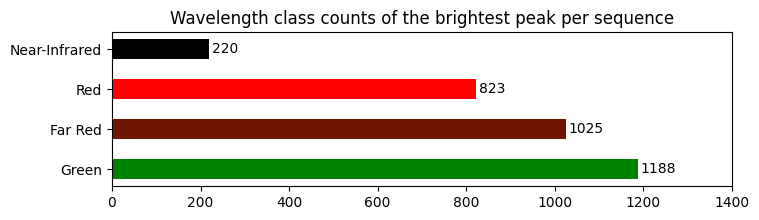

In [20]:
# the 'class 4' column is the wavelength class column
# therefore the brightest peaks are the first character of the strings in that column
# so we slice it to isolate the first character, then use value_counts() to count the occurances
brightest_peak_count = dataset['class 4'].str[:1].value_counts()

# there is a single instance of a wavelength class being labeled as 'unknown', so the slicing above turns that into just 'u'
# this is mentioned in my paper, but it appears to have a Green brightest peak and other unremarkable properties.
# The 2nd peak has presumably missing information, which probably led to its 'unknown' designation and likely was an error in the materials science lab.
# This sequence also has no 3rd or 4th peak.
# Since we only consider means of the first peak, this discrepency is not relevant to this analysis,
# since it does have complete information for the first peak and that is all we use for computation.
# but to make this plot pretty, i dropped it. There is further information about this in the following code block.
brightest_peak_count = brightest_peak_count.drop('u')

labels = ['Green', 'Far Red', 'Red', 'Near-Infrared']
colors = ['green', '#701500', 'red', 'black']

# a skinny plot is fine, this doesnt need to be bigger
fig, ax = plt.subplots(figsize = (8,2))

# horizontal bar chart
bars = ax.barh(labels,
        brightest_peak_count.values, color = colors, height=.5)
# spaces out the values from the bars
plt.bar_label(bars, padding=2)
# labels for the x axis
plt.xticks([0,200,400,600,800,1000,1200,1400])
plt.title("Wavelength class counts of the brightest peak per sequence")
plt.show()

For the sake of clarity, this is the 'unknown' value and its data. Here is a quick summary of what the data means.

The `Sequence` value is GGGACGTGAA, which is a valid DNA sequence and is of length 10, just like every other sequence in this dataset.

`Component 1 b (wavelength)` corresponds to the wavelength of the brightest/first peak, which is 570.888599. This value is under 590, therefore corresponds to a Green wavelength, so `class 4`, ie the 'Wavelength Class' column should really just be valued 'G' for green. Green is by far the most prevalent wavelength class in this dataset, so this is not a very remarkable or notable wavelength.

`Component 1 a log10` is the intensity weight/brightness of the brightest/first peak, which is an unremarkable value of 3.211335.

 `Component 1 c (wavelength)` is the peak width of the brightest/first peak, which is also an unremarkable value of 87.322182.

 There is only one peak, so the rest of the `Component` values are 0 since there are no other peaks to observe properties of. This is also unremarkable as there are many single-peaked sequences in this dataset. I presume there is some missing information in the 2nd peak since the 1st peak looks normal, which somehow led to this being classified as unknown.

 However, the distance matrix is calculated only with respect to the sequence permutation, which is a valid one, and the euclidean distance of the means used later on in the analysis only considers the numerical information of the brightest/first peak, which does have valid, if unremarkable information. Therefore the labeling of this sequence as 'unknown', while admittedly strange, has no effect on any of this analysis.

In [21]:
unknown = dataset.where(dataset['class 4']=='unknown').dropna()

print(unknown[['Sequence','Component 1 a log10', 'Component 1 b (wavelength)',
       'Component 1 c (wavelength)', 'Component 2 a log10',
       'Component 2 b (wavelength)', 'Component 2 c (wavelength)',
       'Component 3 a log10', 'Component 3 b (wavelength)',
       'Component 3 c (wavelength)', 'Component 4 a log10',
       'Component 4 b (wavelength)', 'Component 4 c (wavelength)', 'category1',
       'Label', 'class 4']].transpose())
# since this is a single row of data, it is more readable as a column, so i transposed it for readibility

                                  3189
Sequence                    GGGACGTGAA
Component 1 a log10           3.211335
Component 1 b (wavelength)  570.888599
Component 1 c (wavelength)   87.322182
Component 2 a log10                0.0
Component 2 b (wavelength)         0.0
Component 2 c (wavelength)         0.0
Component 3 a log10                0.0
Component 3 b (wavelength)         0.0
Component 3 c (wavelength)         0.0
Component 4 a log10                0.0
Component 4 b (wavelength)         0.0
Component 4 c (wavelength)         0.0
category1                       single
Label                              0.0
class 4                        unknown


## Create instances of cluster routines.

In [22]:
ward_full, average_full, complete_full, centroid_full, weighted_full, median_full = fitted_cluster_routines(distance_matrix)

distance matrix is of size 3257 x 3257


# Average Linkage Hierarchal Clustering data analysis

In [23]:
threshold = 4.5
# get all the clusters
clusters_avg_full = return_all_clusters(average_full, threshold, all_labels,dataset)
# get the means of all the clusters
means_avg_full = cluster_means(clusters_avg_full)

3257 datapoints comprising 384 clusters with threshold 4.5


# We create a dendrogram of the dataset. While this is visually not as clear of a visual as we would probablylike it to be, it does give us an idea of a range of numbers to experiment with as a threshold. We have selected 4.5 as our threshold, which is marked by the horizontal black line.

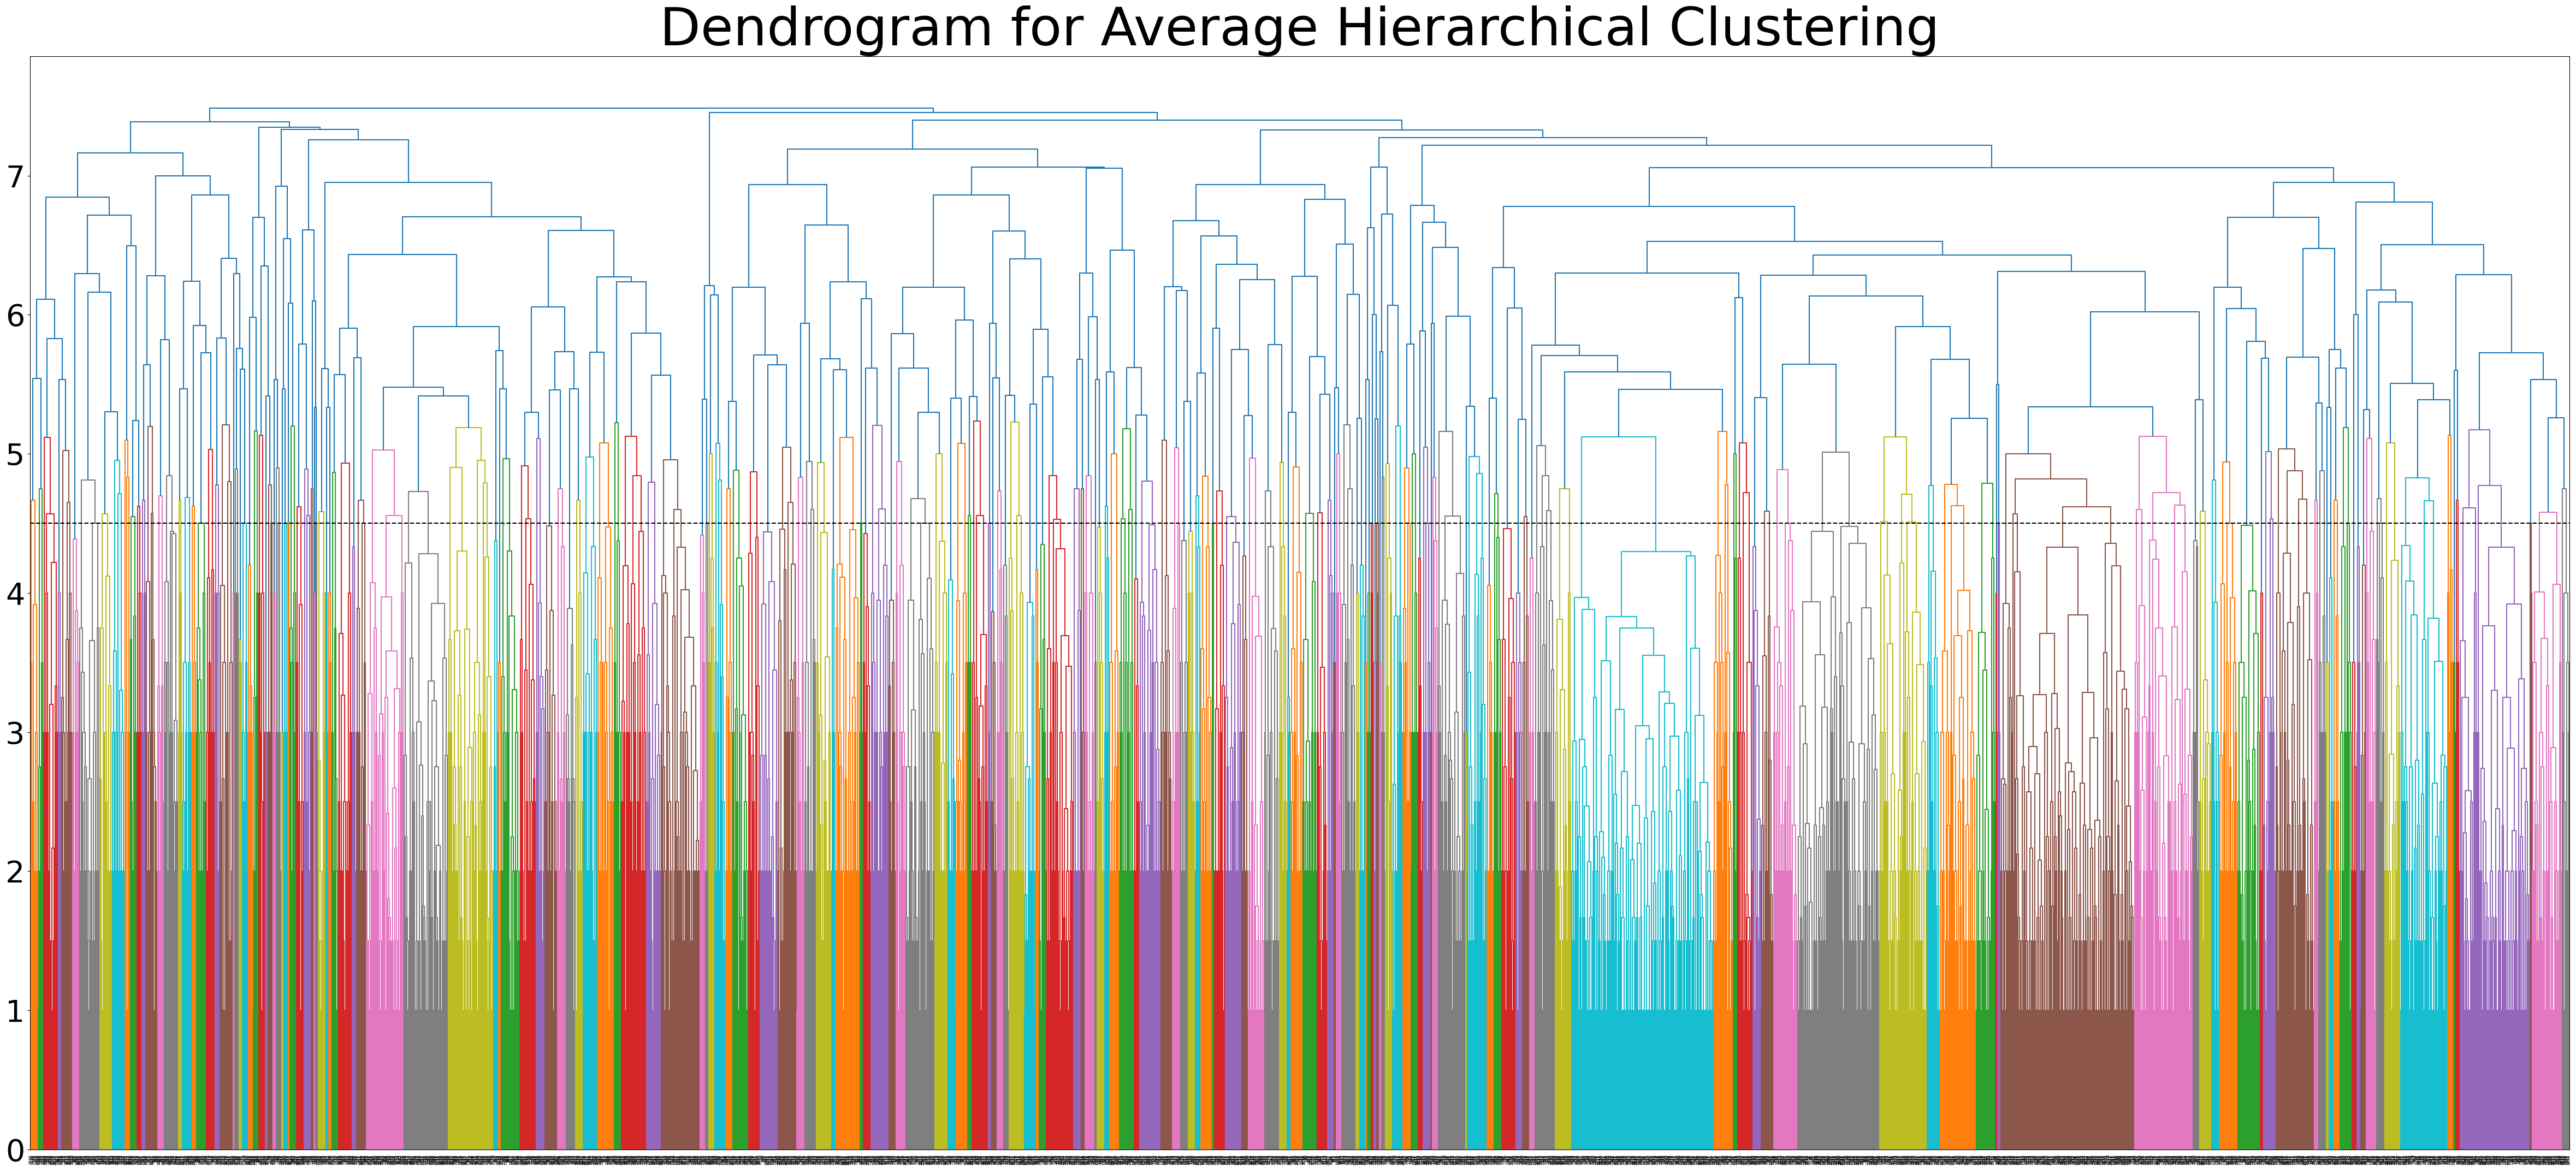

In [24]:
plt.figure(figsize=(60,26))
dendrogram = sch.dendrogram(average_full)
# this shows where we 'cut' the dendrogram.
plt.axhline(threshold, color='black', linestyle='--')
plt.title("Dendrogram for Average Hierarchical Clustering", fontsize = 70)
plt.tick_params(axis='y', labelsize=40)

plt.show()

# We run our cluster of interest algorithm to see what it picks up. Only one cluster makes the cut, cluster 376. some extra information about the cluster is printed out as well.

In [25]:
# we test for all categories
# in testing, i would experiment with omitting the nir ratio category since it was clearly the most restrictive,
# so i designed the option to specify which categories one would like to use. Ultimately, all of them proved usable.
categories = ["peak", "weight", "wav", 'size', 'nir']

# we declare n = 100 (recall we have 384 clusters), and for each category, check the top 100 clusters, and then take
# a set intersection of each group of top 100 clusters to see which ones made it into all 5 lists
top_avg_full = top_category_clusters(means_avg_full, clusters_avg_full, dataset, categories, 100)

# then for each one in the intersection, we create Cluster_Of_Interest class instances and call their report() function
cluster_list_report(top_avg_full, clusters_avg_full, 'average', threshold, dataset)

# however only one cluster made the cut so this cluster_list_report function only iterates once.
# in practice this either iterated under 5 or over 50 times so I still consider this useful.

# the 'u' value that was previously mentioned is in this cluster, for the sake of clarity i just ignore it since
# one more green sequence could not be more irrelevant.

1 clusters meet all criteria.
Cluster labels: {np.int64(376)}


-----------------------------------------

Cluster #376
Size: 18, Linkage: average, threshold: 4.5
Additional Info: None

Distance Counts
2.0    52
3.0    43
4.0    26
1.0    21
5.0     9
6.0     2
Name: count, dtype: int64

Brightest Peak
F    6
N    6
R    4
G    1
u    1
Name: count, dtype: int64

Wavelength Class
FG    4
NF    3
FF    2
NG    2
RG    2
R     2
NN    1
GG    1
un    1
Name: count, dtype: int64


# We observe the brightest peaks of the top 15 clusters near our initial cluster of interest.

Recall,

F -> Far red

N -> Near infrared

R -> Red

G -> Green

In [26]:
# the _ is because we dont really need the dataframe of mean distances, we just want the labels of the top 15
# recall that cluster 376 is the one of interest
_, top15 = cluster_mean_distance(means_avg_full, 376, 15)
print(top15)
# since we have 15 different clusters, it would be helpful to analyze them all, and one of the easiest and
# most effective ways to do that is to check the value_count() of the brightest peak.
# the function below was designed for just that, to aggregate multiple instances of value_count()
cluster_list_wav_count(top15, clusters_avg_full, 'avg', dataset, 4.5, top_2=False)

[325, 320, 145, 84, 46, 254, 3, 361, 333, 135, 226, 33, 309, 39, 203]


,Brightest Peak,count
0,F,26.0
1,N,24.0
2,R,13.0
3,G,12.0


24 near infrareds is pretty great, especially since we have a remarkably low amount of reds and greens in comparison. Far reds are at a comparable count of 26 but that is somewhat expected since they have the 2nd highest wavelength, just below near infrared

# We do the same as above but looking at the top 2 brightest peaks just to see how similar things are

Some of these sequences only have one peak, so there is only a single character in the `Wavelength class` column in those instances. Other sequences have more than one peak, but we are only observing the top 2 brightest peaks so we only include those here, if a second one even exists.

In [27]:
# This is the same thing as above but with top_2 set to true
cluster_list_wav_count(top15,  clusters_avg_full,
                       'avg',   dataset, 4.5, top_2=True)

,Wavelength Class,count
0,F,11.0
10,N,7.0
11,GF,6.0
2,FG,6.0
5,NG,6.0
13,RF,5.0
1,FF,4.0
8,GG,4.0
4,FR,4.0
6,RG,4.0


# We observe the sequences within our cluster of interest

In [28]:
c376 = Cluster_Of_Interest(clusters_avg_full,
                           376, 'average',
                           4.5, dataset)
c376.sequences
# a lot of Gs in the front, a lot of As and Cs in the back.
# this corroborates with an earlier paper on this topic

Index(['GGGACTCTCA', 'GGGCCCGGAA', 'GGGACTGGAC', 'GGGACAGGAA', 'GGGACCGGAA',
       'GGGACCAGAC', 'GGGACCAGAA', 'GGGACCGTAA', 'GGGACTGGAA', 'GGGACGTAAA',
       'AGGACTGGCC', 'GGGACTCGAA', 'GGGAGCGTAA', 'GGGACCTGAA', 'CGGACCGGAA',
       'GGGACGGTAA', 'GGGACGGGAA', 'GGGACGTGAA'],
      dtype='object')